# Primer Dataset
https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer/code

# Analisis Exploratorio

## 1. Que queremos conseguir

* Como influyen ciertos tipos de habitos en las personas para padecer cancer de pulmon
* Como influyen ciertos sintomas medicos en las personas para padecer cancer de pulmon
* Como influyen ciertos sentimientos en las personas para padecer cancer de pulmon


## 2. Generalidades

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/survey lung cancer.csv')
data.columns = data.columns.str.strip()
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
columns = data.columns[:]
data[columns] = data[columns].replace({1: 0, 2: 1})
data['lung_cancer'] = data['lung_cancer'].replace({"YES":1, "NO":0})
data.head()

,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic_disease,fatigue,allergy,wheezing,alcohol_consuming,coughing,shortness_of_breath,swallowing_difficulty,chest_pain,lung_cancer
0,M,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,M,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,F,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,M,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,F,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [ ]:
data.dtypes

gender                   object
age                       int64
smoking                   int64
yellow_fingers            int64
anxiety                   int64
peer_pressure             int64
chronic_disease           int64
fatigue                   int64
allergy                   int64
wheezing                  int64
alcohol_consuming         int64
coughing                  int64
shortness_of_breath       int64
swallowing_difficulty     int64
chest_pain                int64
lung_cancer               int64
dtype: object

In [ ]:
data.dtypes.value_counts()

int64     15
object     1
dtype: int64

In [ ]:
data.select_dtypes(include=['int64']).nunique()

age                      39
smoking                   2
yellow_fingers            2
anxiety                   2
peer_pressure             2
chronic_disease           2
fatigue                   2
allergy                   2
wheezing                  2
alcohol_consuming         2
coughing                  2
shortness_of_breath       2
swallowing_difficulty     2
chest_pain                2
lung_cancer               2
dtype: int64

In [ ]:
data.isnull().values.any()

False

In [ ]:
data.duplicated().sum()

33

In [ ]:
data = data.drop_duplicates()
data.shape

(276, 16)

In [ ]:
data.describe().loc[['min','max']]

,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic_disease,fatigue,allergy,wheezing,alcohol_consuming,coughing,shortness_of_breath,swallowing_difficulty,chest_pain,lung_cancer
min,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,87.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. Revision de los datos continuos, estadistica descriptiva

In [ ]:
!pip install fitter
from fitter import Fitter, get_common_distributions, get_distributions

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,0.037805,1246.865162,1257.726364,inf,0.067695,0.152193
norm,0.037805,1244.863947,1252.104749,inf,0.067695,0.152191
gamma,0.037855,1280.049624,1290.910826,inf,0.058820,0.284021
chi2,0.037957,1278.003255,1288.864458,inf,0.063048,0.213417
cauchy,0.041164,1015.094377,1022.335178,inf,0.087987,0.026174


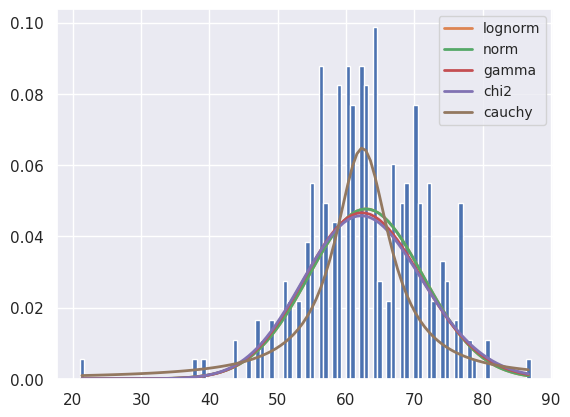

In [ ]:
fit = data[data.columns[1]].values

f = Fitter(fit,distributions= get_common_distributions())
f.fit()
f.summary()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,0.037805,1246.865162,1257.726364,inf,0.067695,0.152193
norm,0.037805,1244.863947,1252.104749,inf,0.067695,0.152191
gamma,0.037855,1280.049624,1290.910826,inf,0.058820,0.284021
beta,0.038305,1159.229420,1173.711023,inf,0.086511,0.030213
burr,0.038543,1136.357152,1150.838755,inf,0.070843,0.119370


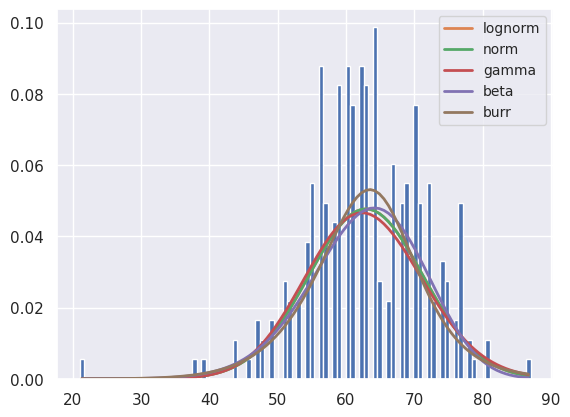

In [ ]:
fit = data[data.columns[1]].values

f = Fitter(fit,distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
           #distributions= get_common_distributions())
f.fit()
f.summary()

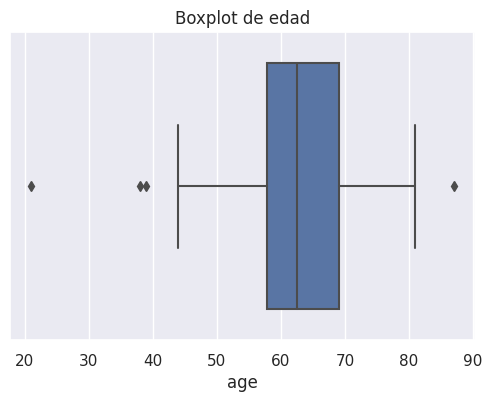

In [ ]:
plt.figure(figsize = (6,4))
sns.boxplot(x=data["age"])
plt.title("Boxplot de edad", fontsize = 12)
plt.show()

In [ ]:
bp = pd.DataFrame.boxplot(data["age"], return_type='dict')
whiskers = [whiskers.get_ydata() for whiskers in bp["whiskers"]]
print(data[data.columns[1]].describe())
print("lower whiskers: "+str(whiskers[0]))
print("upper whiskers: "+str(whiskers[1]))
plt.close()

count    276.000000
mean      62.909420
std        8.379355
min       21.000000
25%       57.750000
50%       62.500000
75%       69.000000
max       87.000000
Name: age, dtype: float64
lower whiskers: [57.75 44.  ]
upper whiskers: [69. 81.]


### 3.1 Correlacion

<ipython-input-114-454e1e9633d3>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot = True, cmap="RdBu", fmt=".3f")


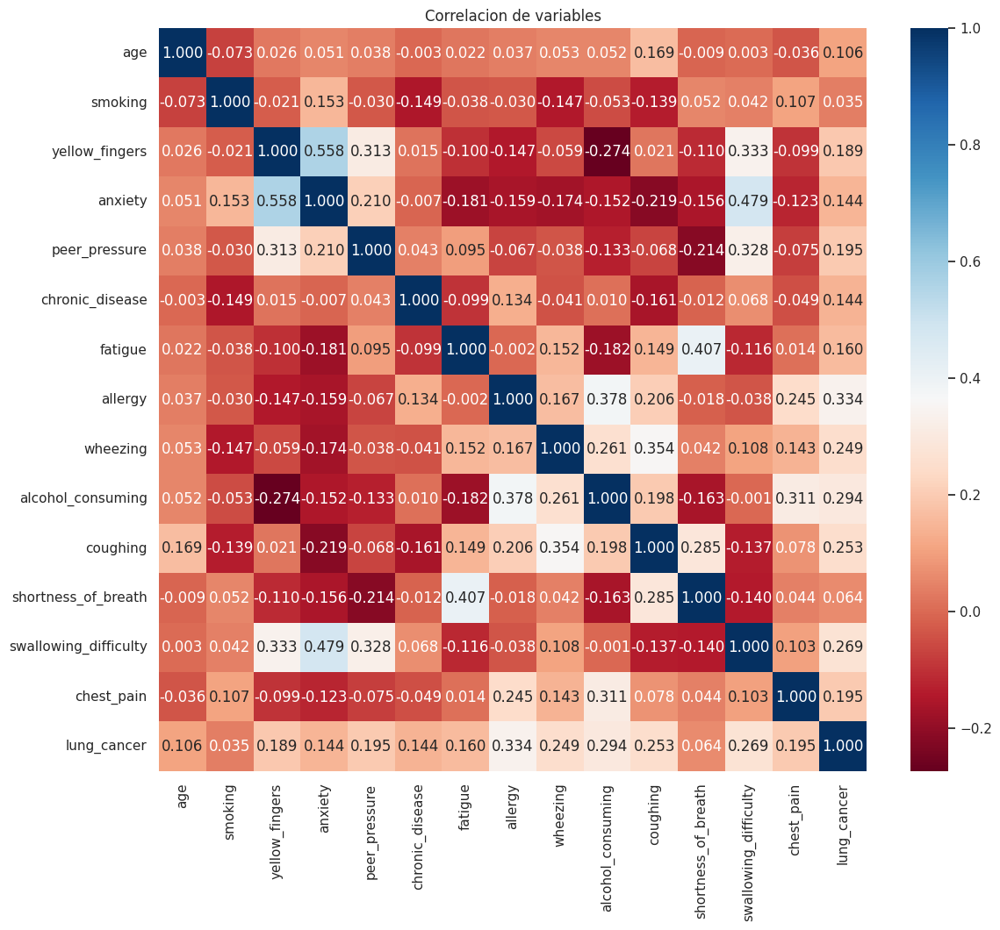

In [ ]:
plt.figure(figsize = (13,11))
sns.heatmap(data.corr(), annot = True, cmap="RdBu", fmt=".3f")
plt.title("Correlacion de variables", fontsize = 12)
plt.show()

<ipython-input-115-f73204e981ec>:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data,x='lung_cancer',shade=True,fill=True,color='red')


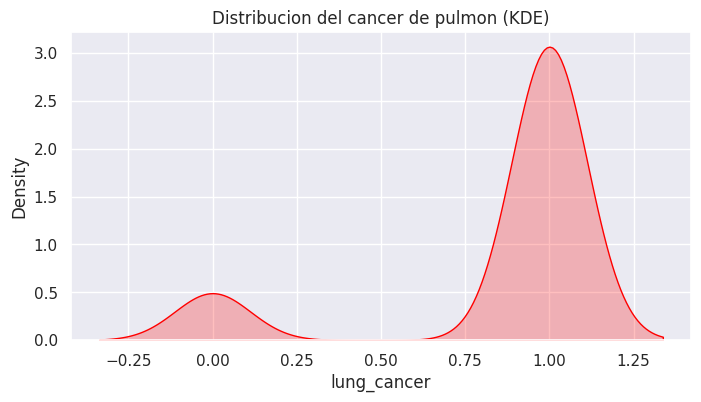

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=data,x='lung_cancer',shade=True,fill=True,color='red')
plt.title('Distribucion del cancer de pulmon (KDE)')
plt.show()

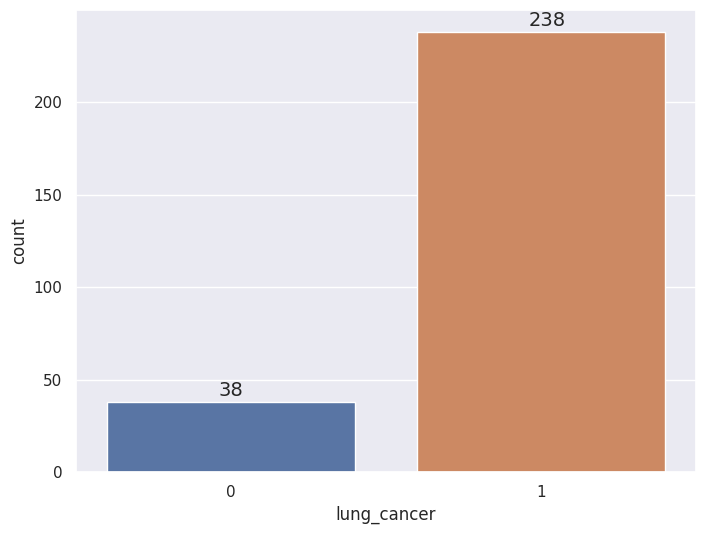

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x=data['lung_cancer'])
target_count = data.lung_cancer.value_counts()
plt.annotate(text=str(target_count[0]), xy=(-0.04,3+target_count[0]), size=14)
plt.annotate(text=str(target_count[1]), xy=(0.96,3+target_count[1]), size=14)
plt.show()

## 4. Interacciones entre datos

### Edad

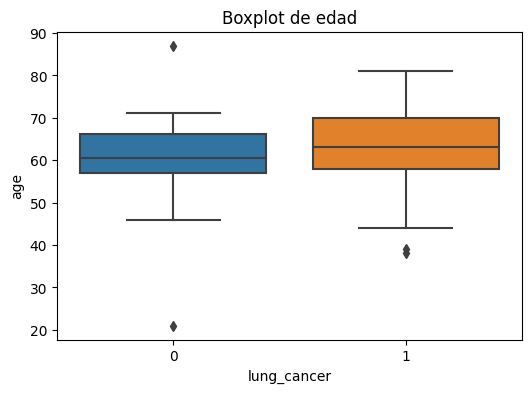

In [ ]:
plt.figure(figsize = (6,4))
sns.boxplot(x=data["lung_cancer"],y=data["age"])
plt.title("Boxplot de edad", fontsize = 12)
plt.show()

In [ ]:
# bp = data.boxplot(column=['age'],by="lung_cancer", return_type='dict')
# whiskers2 = [whisker.get_ydata() for whisker in bp["whiskers"]]
print("Tienen Riesgo de Cancer")
print(data[data['lung_cancer']==1]['age'].describe())
print("No tienenRiesgo de Cancer")
print(data[data['lung_cancer']==0]['age'].describe())
# print("lower whiskers: "+str(whiskers[0]))
# print("upper whiskers: "+str(whiskers[1]))
# plt.close()
# bp

Tienen Cancer
count    238.000000
mean      63.264706
std        8.105924
min       38.000000
25%       58.000000
50%       63.000000
75%       70.000000
max       81.000000
Name: age, dtype: float64
No tienen Cancer
count    38.000000
mean     60.684211
std       9.751245
min      21.000000
25%      57.000000
50%      60.500000
75%      66.250000
max      87.000000
Name: age, dtype: float64


Text(0.5, 1.0, 'Gráfico de Violín del Cancer de Pulmon respecto la Edad')

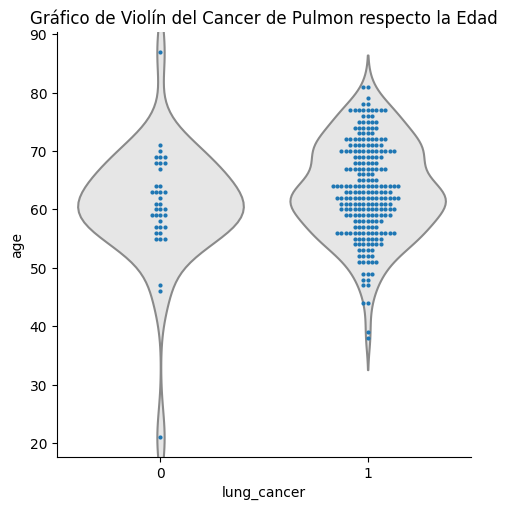

In [ ]:
sns.catplot(data=data, x="lung_cancer", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="lung_cancer", y="age", size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto la Edad')


In [ ]:
data.groupby(by=["lung_cancer","age"]).size()

lung_cancer  age
0            21      1
             46      1
             47      1
             55      3
             56      2
             57      3
             58      1
             59      4
             60      3
             61      2
             62      1
             63      4
             64      2
             67      1
             68      3
             69      3
             70      1
             71      1
             87      1
1            38      1
             39      1
             44      2
             47      2
             48      2
             49      3
             51      5
             52      4
             53      4
             54      7
             55      7
             56     14
             57      6
             58      7
             59     11
             60     13
             61     12
             62     15
             63     11
             64     16
             65      5
             66      4
             67     10
             68  

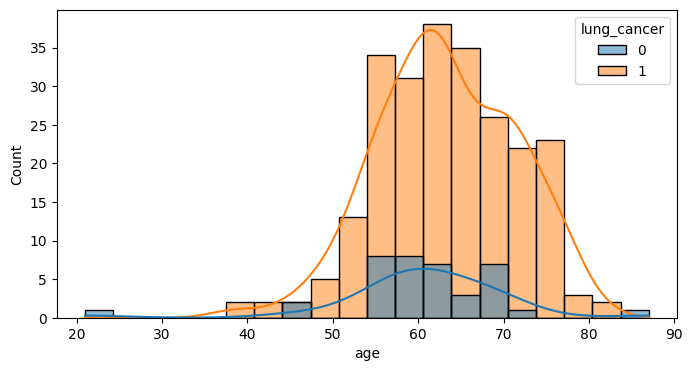

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=data,x='age',hue="lung_cancer",kde=True,fill=True,color='red')
plt.show()

### Genero

gender,F,M
lung_cancer,,
0,21,17
1,113,125


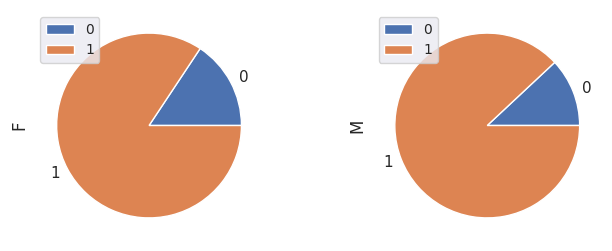

In [ ]:
pie_data = data.groupby(by=["gender","lung_cancer"]).size().unstack(fill_value=0,level=0)
pie_data.plot.pie(subplots=True,figsize=(8, 3))
data.groupby(by=["gender","lung_cancer"]).size().unstack(fill_value=0,level=0)

* Columnas para clasificar: 'age','gender'
* Columnas de habitos: 'smoking', 'alcohol_consuming'
* Columnas de sintomas: 'yellow_fingers', 'chronic_disease', 'fatigue', 'allergy', 'wheezing', 'coughing', 'shortness_of_breath', 'swallowing_difficulty', 'chest_pain'
* Columnas de estados: , 'anxiety', 'peer_pressure'

### Columnas de habitos

smoking  lung_cancer
0        0               19
         1              107
1        0               19
         1              131
dtype: int64

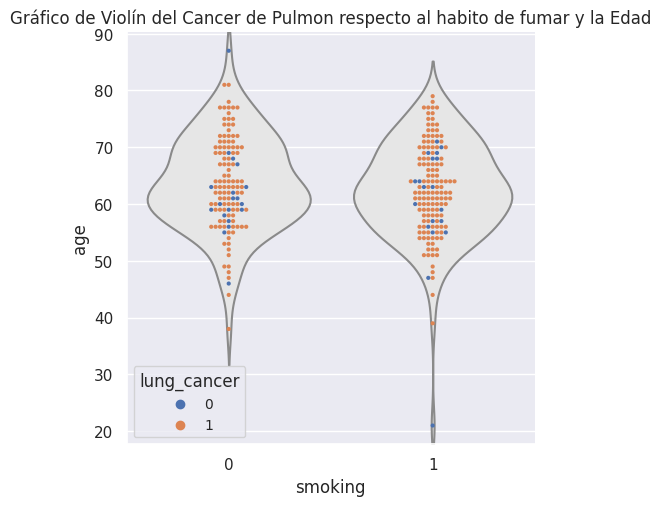

In [ ]:
sns.catplot(data=data, x="smoking", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="smoking", y="age", hue='lung_cancer', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto al habito de fumar y la Edad')
data.groupby(by=["smoking","lung_cancer"]).size()

<ipython-input-24-519a78722146>:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data,x='smoking',hue="lung_cancer",shade=True,fill=True,color='red')


smoking  lung_cancer
0        0               19
         1              107
1        0               19
         1              131
dtype: int64

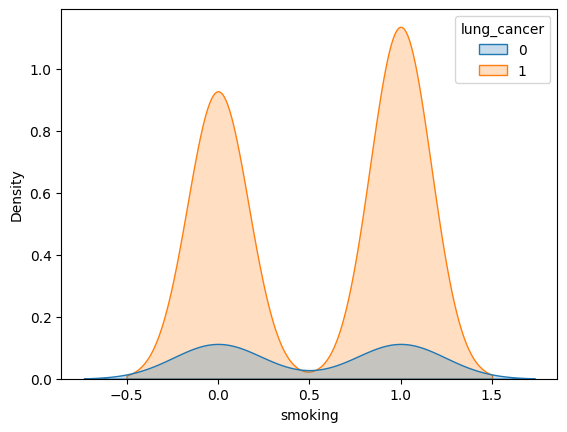

In [ ]:
sns.kdeplot(data=data,x='smoking',hue="lung_cancer",shade=True,fill=True,color='red')
data.groupby(by=["smoking","lung_cancer"]).size()

gender  smoking  lung_cancer
F       0        0              11
                 1              53
        1        0              10
                 1              60
M       0        0               8
                 1              54
        1        0               9
                 1              71
dtype: int64

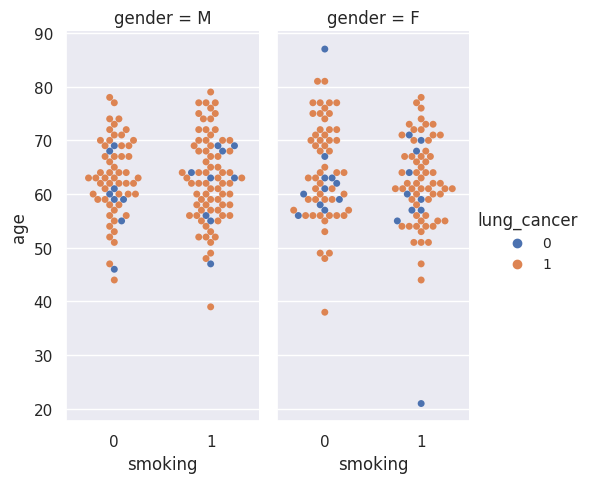

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="smoking", y="age", hue="lung_cancer", col="gender",
    aspect=.5
)
data.groupby(by=["gender","smoking","lung_cancer"]).size()

alcohol_consuming  lung_cancer
0                  0               32
                   1              105
1                  0                7
                   1              165
dtype: int64

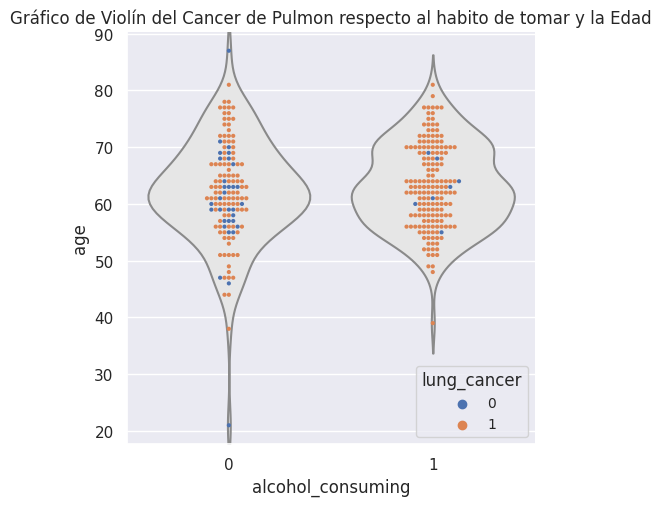

In [ ]:
sns.catplot(data=data, x="alcohol_consuming", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="alcohol_consuming", y="age", hue='lung_cancer', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto al habito de tomar y la Edad')
data.groupby(by=["alcohol_consuming","lung_cancer"]).size()

<ipython-input-99-e1d30bb9ccb5>:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data,x='alcohol_consuming',hue="lung_cancer",shade=True,fill=True,color='red')


alcohol_consuming  lung_cancer
0                  0               32
                   1              105
1                  0                7
                   1              165
dtype: int64

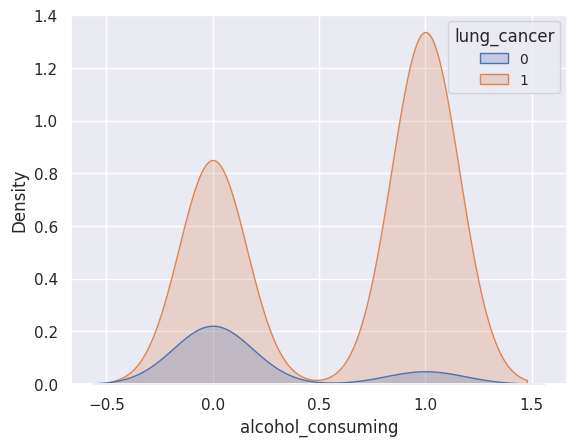

In [ ]:
sns.kdeplot(data=data,x='alcohol_consuming',hue="lung_cancer",shade=True,fill=True,color='red')
data.groupby(by=["alcohol_consuming","lung_cancer"]).size()

gender  alcohol_consuming  lung_cancer
F       0                  0               21
                           1               69
        1                  1               44
M       0                  0               10
                           1               24
        1                  0                7
                           1              101
dtype: int64

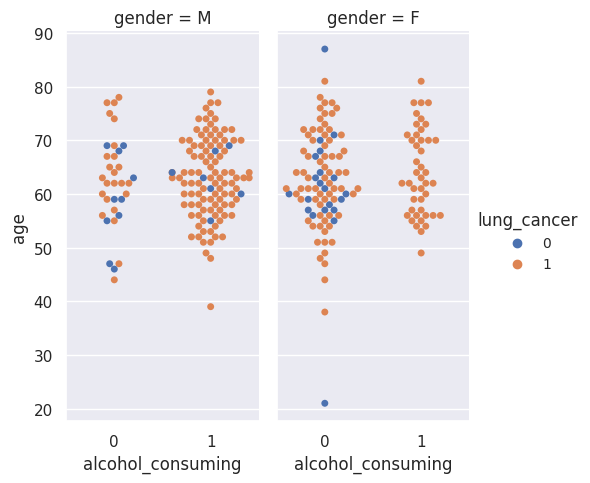

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="alcohol_consuming", y="age", hue="lung_cancer", col="gender",
    aspect=.5
)
data.groupby(by=["gender","alcohol_consuming","lung_cancer"]).size()

In [ ]:
plt.figure(figsize=(8,4))
sns.bloxplot(data=data,x='age',hue="lung_cancer",shade=True,fill=True,color='red')
plt.show()

### Columnas de estados mentales

anxiety  lung_cancer
0        0               26
         1              113
1        0               12
         1              125
dtype: int64

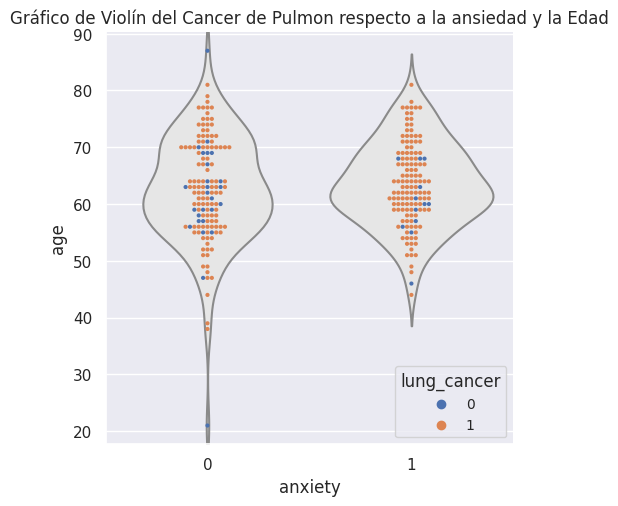

In [ ]:
sns.catplot(data=data, x="anxiety", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="anxiety", y="age", hue='lung_cancer', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto a la ansiedad y la Edad')
data.groupby(by=["anxiety","lung_cancer"]).size()

anxiety  lung_cancer
0        0               26
         1              113
1        0               12
         1              125
dtype: int64


<ipython-input-35-52a9b518e7be>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data,x='anxiety',hue="lung_cancer",shade=True,fill=True,color='red')


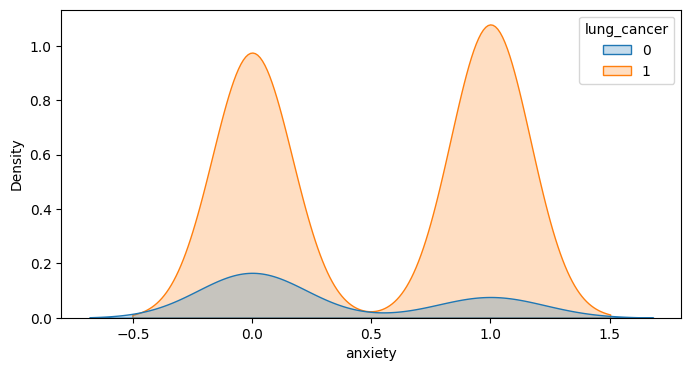

In [ ]:
print(data.groupby(by=["anxiety","lung_cancer"]).size())
plt.figure(figsize=(8,4))
sns.kdeplot(data=data,x='anxiety',hue="lung_cancer",shade=True,fill=True,color='red')

plt.show()

gender  anxiety  lung_cancer
F       0        0              17
                 1              40
        1        0               4
                 1              73
M       0        0               9
                 1              73
        1        0               8
                 1              52
dtype: int64

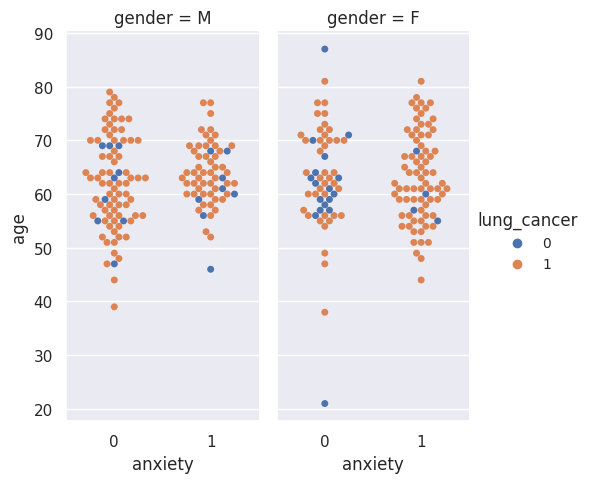

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="anxiety", y="age", hue="lung_cancer", col="gender",
    aspect=.5
)
data.groupby(by=["gender","anxiety","lung_cancer"]).size()

anxiety  lung_cancer
0        0               26
         1              113
1        0               12
         1              125
dtype: int64


<ipython-input-41-2004f8bdb128>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data.loc[data['gender'] == 'F'],x='anxiety',hue="lung_cancer",shade=True,fill=True,color='red')


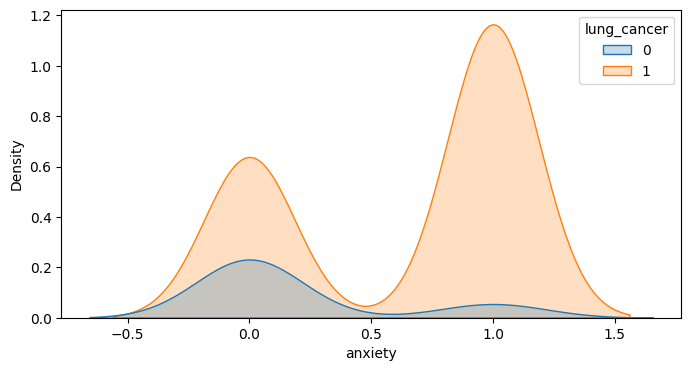

In [ ]:
print(data.groupby(by=["anxiety","lung_cancer"]).size())
plt.figure(figsize=(8,4))
sns.kdeplot(data=data.loc[data['gender'] == 'F'],x='anxiety',hue="lung_cancer",shade=True,fill=True,color='red')
plt.show()

peer_pressure  lung_cancer
0              0               28
               1              108
1              0               10
               1              130
dtype: int64

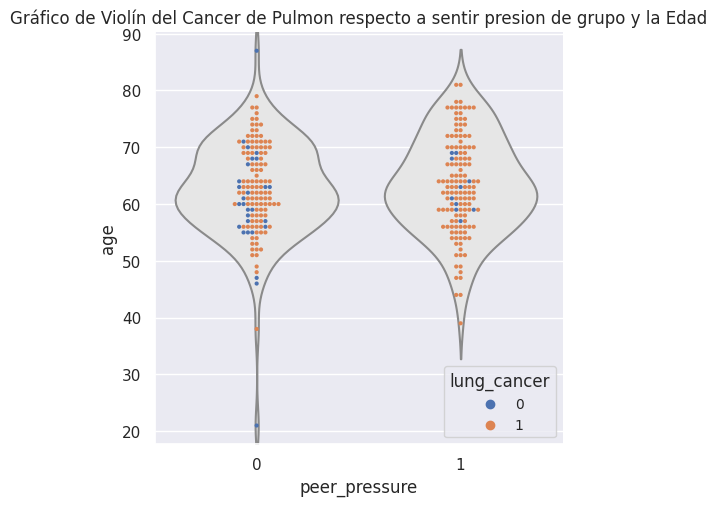

In [ ]:
sns.catplot(data=data, x="peer_pressure", y="age", kind="violin", color=".9", inner=None)
sns.swarmplot(data=data, x="peer_pressure", y="age", hue='lung_cancer', size=3)
plt.title('Gráfico de Violín del Cancer de Pulmon respecto a sentir presion de grupo y la Edad')
data.groupby(by=["peer_pressure","lung_cancer"]).size()

peer_pressure  lung_cancer
0              0               29
               1              125
1              0               10
               1              145
dtype: int64


<ipython-input-97-23b8338776aa>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data,x='peer_pressure',hue="lung_cancer",shade=True,fill=True,color='red')


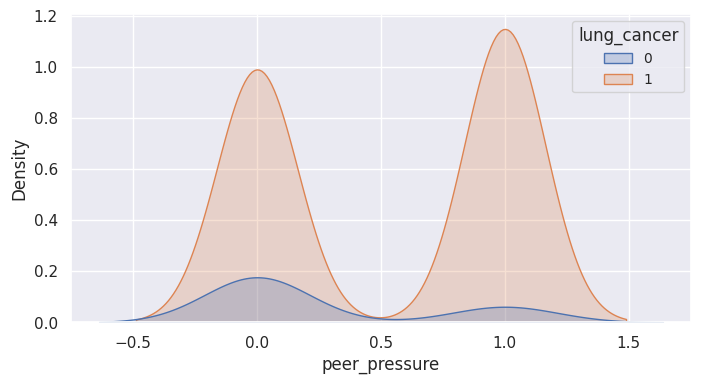

In [ ]:
print(data.groupby(by=["peer_pressure","lung_cancer"]).size())
plt.figure(figsize=(8,4))
sns.kdeplot(data=data,x='peer_pressure',hue="lung_cancer",shade=True,fill=True,color='red')
plt.show()

gender  peer_pressure  lung_cancer
F       0              0              18
                       1              30
        1              0               3
                       1              83
M       0              0              10
                       1              78
        1              0               7
                       1              47
dtype: int64

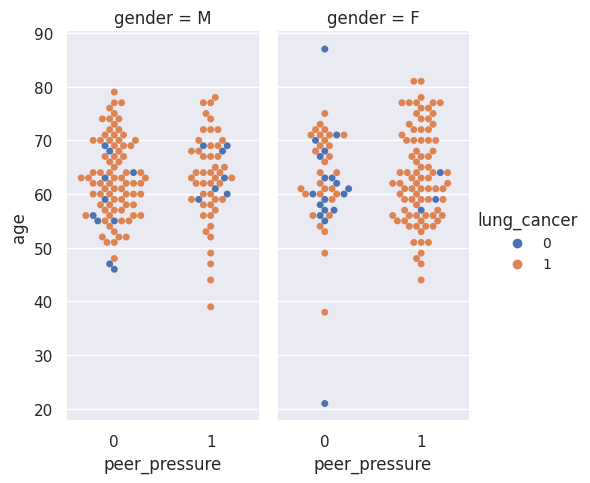

In [ ]:
sns.catplot(
    data=data, kind="swarm",
    x="peer_pressure", y="age", hue="lung_cancer", col="gender",
    aspect=.5
)
data.groupby(by=["gender","peer_pressure","lung_cancer"]).size()

peer_pressure  lung_cancer
0              0               28
               1              108
1              0               10
               1              130
dtype: int64


<ipython-input-39-bb7e5c4ad1a2>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data.loc[data['gender'] == 'F'],x='peer_pressure',hue="lung_cancer",shade=True,fill=True,color='red')


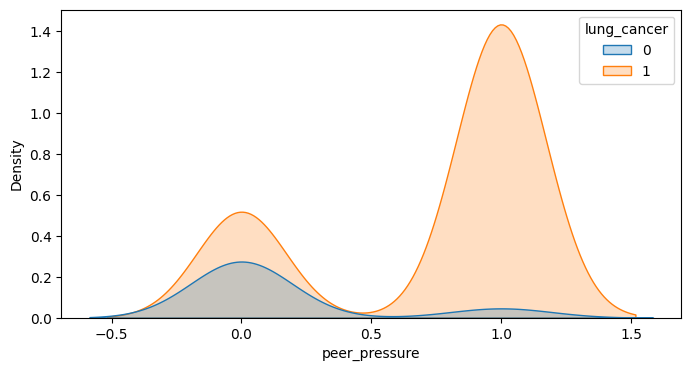

In [ ]:
print(data.groupby(by=["peer_pressure","lung_cancer"]).size())
plt.figure(figsize=(8,4))
sns.kdeplot(data=data.loc[data['gender'] == 'F'],x='peer_pressure',hue="lung_cancer",shade=True,fill=True,color='red')
plt.show()

### Columnas de sintomas

In [ ]:
constant_features = data.nunique()
constant_features = constant_features.loc[constant_features.values==2].index
constant_features[:-1]

Index(['gender', 'smoking', 'yellow_fingers', 'anxiety', 'peer_pressure',
       'chronic_disease', 'fatigue', 'allergy', 'wheezing',
       'alcohol_consuming', 'coughing', 'shortness_of_breath',
       'swallowing_difficulty', 'chest_pain'],
      dtype='object')

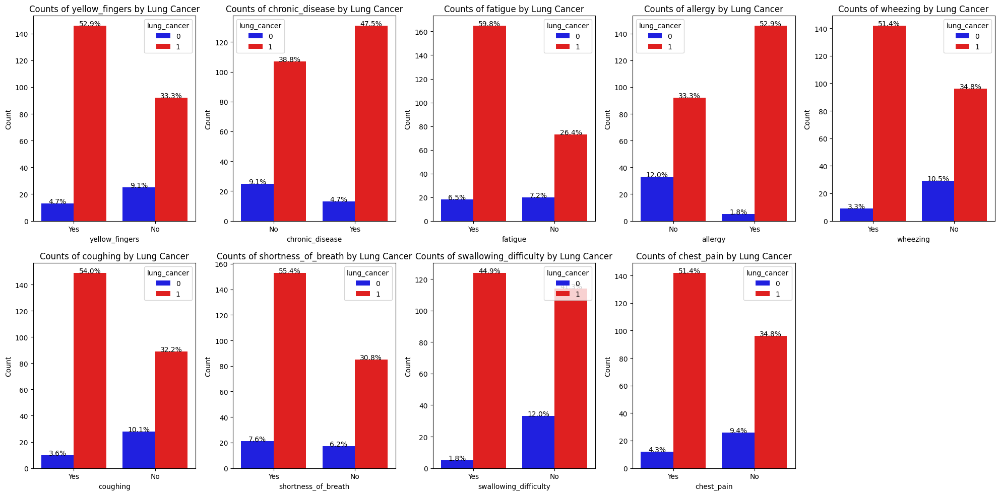

In [ ]:
data_copy = data.copy()
health_factors = ['yellow_fingers', 'chronic_disease', 'fatigue', 'allergy', 'wheezing', 'coughing', 'shortness_of_breath', 'swallowing_difficulty', 'chest_pain']
plt.figure(figsize=(20, 10))
for i, factor in enumerate(health_factors):
    plt.subplot(2, 5, i + 1)
    data_copy[factor] = data_copy[factor].map({0: 'No', 1: 'Yes'})
    palette = ['blue','red']
    ax = sns.countplot(data=data_copy, x=factor, hue='lung_cancer', palette=palette)
    plt.title(f'Counts of {factor} by Lung Cancer')
    plt.xlabel(factor)
    plt.ylabel('Count')
    total_count = len(data_copy)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height/total_count*100:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center')
sns.set(rc={'legend.fontsize': 10})
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data_copy['yellow_fingers'] + data_copy['chronic_disease'] + data_copy['allergy'] + data_copy['fatigue'] + data_copy['wheezing'] + data_copy['coughing'] + data_copy['shortness_of_breath'] + data_copy['swallowing_difficulty'] + data_copy['chest_pain'], data_copy['lung_cancer'])
chi2, p, _, _ = chi2_contingency(contingency_table)
alpha = 0.05
if p < alpha:
    print("There is a significant relationship between health factors and lung cancer.")
else:
    print("There is no significant relationship between health factors and lung cancer.")

There is a significant relationship between health factors and lung cancer.


## Algunas Conclusiones
* Sobre como influyen ciertos tipos de habitos en las personas para padecer cancer de pulmon
* Sobre como influyen ciertos sintomas medicos en las personas para padecer cancer de pulmon
* Sobre como influyen ciertos sentimientos en las personas para padecer cancer de pulmon

1. Sobre fumar y beber alcohol:
  * Hay una cantidad ligeramente mayor de personas que fuman y tienen cancer de pulmon que las que no fuman y tienen cancer de pulmon (107 a 131).
  * Hay una cantidad minimamente menor de personas del genero femenino que tienen cancer de pulmon que las personas del genero masculino que tienen cancer de pulmon (113 a 125).
  * La cantidad personas que consumen bebidas alcoholicas y tienen cancer de pulmon es considerablemente mayor a las que no consumen y tienen cancer de pulmon (165 a 105).
  * Todas las personas del genero femenino que consumen bebidas alcoholicas tienen cancer de pulmon (44).
  * La mayoria de personas del genero masculino que consumen bebidas alcoholicas tienen cancer de pulmon (101).

2. Sobre los sintomas medicos:
  * La mayoria de personas que padecen estos sintomas presentan tambien cancer de pulmon.
3. Sobre los sentimientos (ansiedad y presion de grupo):
  * Hay una cantidad ligeramente mayor de personas con ansiedad que tienen cancer de pulmon que las personas sin ansiedad con cancer de pulmon (125 a 113).
  * La mayoria de personas del genero femenino con ansiedad tienen cancer de pulmon (73)
  * Hay una cantidad ligeramente mayor de personas que sienten presion de grupo y tienen cancer de pulmon que las que no y tienen cancer de pulmon (108 a 130).
  * La mayoria de personas del genero femenino que sienten presion de grupo tienen cancer de pulmon (47)

4. Sobre el dataset en general:
  * Todos los datos son categoricos (15) excepto la edad que es continua.
  * No hay valores nulos ni unicos.
  * Hay 33 valores duplicados.
  * La edad maxima y minima, es 87 y 21.
  * La edad se ajusta mas a una distribucion normal siendo la segunda mejor la distrubucion lognorm
  * Hay outliers en la edad.
  * La mitad de las personas del dataset son de edades entre 57.75 y 69 años.
  * Sobre la matriz de correlacion, respecto a la variable objetivo; todas las demas variables son independientes.
  * Hay mas personas con riesgo de padecer cancer de pulmon que las que no. (Desbalanceado)

# Modelamiento

## Imbalanced Data

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

data['gender'] = data['gender'].replace({"F":1, "M":0})

X = data.drop('lung_cancer',axis=1)
Y = data['lung_cancer']

### SMOTE AND ROS

In [ ]:
ros = RandomOverSampler(sampling_strategy='minority')
smote = SMOTE(sampling_strategy='minority')
X_resampled, Y_resampled = ros.fit_resample(X, Y)
#X_resampled, Y_resampled = smote.fit_resample(X, Y)
print("Counter:", Counter(Y_resampled))

Counter: Counter({1: 238, 0: 238})


##

In [ ]:
# from sklearn.model_selection import train_test_split

In [ ]:
# trainX, testX, trainY, testY = train_test_split(X_resampled, Y_resampled, train_size=.7, test_size = .3)

## Testing and Explanation

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier
from numpy import mean, std
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=b764d133aa4bc6fbb478d630a0b542c064f8598e3a737d91ddc1c4eaf78a47d2
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


### SVC

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'C':[1,10,100],
    'gamma':[1,0.1,0.01,0.001],
    'kernel':['linear','rbf']
    }
svc_cv = GridSearchCV(estimator=SVC(probability=True), param_grid=grid, cv= 5,scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
# svc_cv.fit(trainX, trainY)
svc_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['linear', 'rbf']},
             refit='accuracy',
             scoring=['accuracy', 'f1', 'recall', 'precision'])

In [ ]:
svc_cv.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
svc_cv.cv_results_

{'mean_fit_time': array([0.32668543, 0.08078303, 0.28955197, 0.05074754, 0.33896875,
        0.05236301, 0.23690925, 0.06904407, 0.62524357, 0.0298739 ,
        0.61773634, 0.02167802, 0.56929784, 0.02400584, 0.93288789,
        0.03105392, 7.7796381 , 0.03056545, 8.88543429, 0.04221396,
        6.21688638, 0.02632174, 4.74167271, 0.02740202]),
 'std_fit_time': array([1.50496983e-01, 1.44160881e-02, 9.40173399e-02, 1.04301984e-02,
        1.35768305e-01, 9.48300775e-04, 6.86526486e-02, 7.02865905e-03,
        1.99533942e-01, 6.32088517e-04, 2.40176724e-01, 3.86624126e-04,
        1.05149506e-01, 3.55341322e-04, 4.05612191e-01, 1.25021288e-03,
        3.89130751e+00, 1.46848733e-03, 4.77919302e+00, 3.50301749e-03,
        4.27802954e+00, 1.85583544e-03, 1.36975344e+00, 1.33069180e-03]),
 'mean_score_time': array([0.01507578, 0.01743274, 0.01303716, 0.01435299, 0.02266049,
        0.01253319, 0.01094651, 0.0149271 , 0.00658927, 0.00791397,
        0.00667458, 0.00686741, 0.00662441, 0.00

In [ ]:
# svc = SVC(probability=True, C= 1, gamma= 1, kernel= 'rbf')
# cv = cross_val_score(svc_cv,X_resampled, Y_resampled,cv=5)
# print(mean(cv), '+/-', std(cv))

#### Test And Metrics

In [ ]:
# from sklearn.metrics import (accuracy_score,
#                              f1_score,
#                              classification_report)

In [ ]:
# # svc.fit(trainX,trainY)
# y_pred_svc = svc_cv.predict(testX)

# #assess accuracy
# svc_cv_acc = accuracy_score(testY, y_pred_svc)
# svc_cv_f1 = f1_score(testY, y_pred_svc)
# svc_cv_report = classification_report(testY, y_pred_svc)
# print('SVC test accuracy: {}'.format(svc_cv_acc))
# print('SVC test f1: {}'.format(svc_cv_f1))
# print('SVC classification report: ')
# print(svc_cv_report)

In [ ]:
def get_metrics(model, scoring):
  scores = []
  for score in scoring:
    idx = np.where(model.cv_results_['rank_test_'+score] == 1)
    scores = scores + [{('best_test_'+score):model.cv_results_['mean_test_'+score][idx].max()},
                       {('best_test_'+score+'_std'):model.cv_results_['std_test_'+score][idx].max()}]
  return scores

In [ ]:
svc_scores = get_metrics(svc_cv, ['accuracy','f1','precision','recall'])
svc_scores

[{'best_test_accuracy': 0.9936842105263157},
 {'best_test_accuracy_std': 0.008421052631578935},
 {'best_test_f1': 0.9935941432166551},
 {'best_test_f1_std': 0.008522192485084394},
 {'best_test_precision': 1.0},
 {'best_test_precision_std': 0.0},
 {'best_test_recall': 0.9874113475177305},
 {'best_test_recall_std': 0.016711874706309464}]

In [ ]:
# idx = np.where(svc_cv.cv_results_['mean_test_precision'] == svc_cv.best_score_)
# print("bests std: ", svc_cv.cv_results_['std_test_score'][idx])

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["No Cancer","Cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", svc_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], svc_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Prediction :  [1]
Actual :      1


In [ ]:
explanation.as_list()

[('57.00 < age <= 62.00', -0.0035952217825529946),
 ('yellow_fingers <= 0.00', -0.002125219177184058),
 ('chest_pain <= 0.00', -0.002051537162348436),
 ('alcohol_consuming <= 0.00', -0.0020161798970326876),
 ('allergy <= 0.00', -0.0019996395824741432),
 ('swallowing_difficulty <= 0.00', -0.0018871362675047753),
 ('wheezing <= 0.00', -0.0018849123672159858),
 ('coughing <= 0.00', -0.0018616537758254605),
 ('peer_pressure <= 0.00', -0.0014697807051014457),
 ('0.00 < gender <= 1.00', -0.0012174717286225687),
 ('anxiety <= 0.00', -0.000927255703455346),
 ('0.00 < fatigue <= 1.00', -0.0007946272017655262),
 ('0.00 < chronic_disease <= 1.00', 0.0006477888070795241),
 ('0.00 < shortness_of_breath <= 1.00', -0.0005307890974794811),
 ('smoking <= 0.00', -0.0003239970499638519)]

### LogisticRegression

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'penalty':['l2'],
    'C': [0.001,0.01,0.1,1,10,100,1000]
    }
lr_cv = GridSearchCV(estimator=LogisticRegression(max_iter=5000), param_grid=grid, cv= 5
                     ,scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
lr_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             refit='accuracy',
             scoring=['accuracy', 'f1', 'recall', 'precision'])

In [ ]:
lr_cv.best_params_

{'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}

In [ ]:
lr_cv.cv_results_

{'mean_fit_time': array([0.00956178, 0.0081193 , 0.0030993 , 0.14299989, 0.14948187,
        0.0077239 , 0.01007915, 0.00371704, 0.01638303, 0.02055945,
        0.0094172 , 0.01548409, 0.00308881, 0.04686952, 0.07019234,
        0.01359949, 0.02545514, 0.00328131, 0.12388358, 0.17620211,
        0.01438985, 0.0336555 , 0.00344167, 0.20451126, 0.25064516,
        0.01501136, 0.0355402 , 0.00347586, 0.22200689, 0.42320199,
        0.02317109, 0.05262594, 0.0062212 , 0.29402699, 0.26820822]),
 'std_fit_time': array([5.20739802e-03, 3.95750209e-03, 4.40565682e-04, 3.03958317e-02,
        7.41404549e-02, 8.83054856e-04, 2.23859064e-03, 1.28667664e-03,
        7.85792331e-03, 2.06135280e-03, 7.70230113e-04, 2.20521221e-03,
        2.07073288e-04, 8.86231243e-03, 3.96959415e-03, 6.10258807e-04,
        7.47027324e-03, 3.27343843e-04, 1.55263327e-02, 1.10615936e-02,
        7.80763247e-04, 4.34875177e-03, 1.25911973e-04, 2.96287738e-02,
        1.85019065e-02, 4.59982724e-04, 6.97098136e-03, 7

In [ ]:
# lr = LogisticRegression(max_iter = 2000, C =  1000, penalty =  'l2', solver = 'liblinear')
# cv = cross_val_score(lr,trainX,trainY,cv=5)
# print(mean(cv), '+/-', std(cv))

#### Test And Metrics

In [ ]:
lr_scores = get_metrics(lr_cv, ['accuracy','f1','precision','recall'])
lr_scores

[{'best_test_accuracy': 0.9033333333333333},
 {'best_test_accuracy_std': 0.03491360307819157},
 {'best_test_f1': 0.9002879723272983},
 {'best_test_f1_std': 0.038018885727436266},
 {'best_test_precision': 0.9277347652347652},
 {'best_test_precision_std': 0.050481378071630445},
 {'best_test_recall': 0.949290780141844},
 {'best_test_recall_std': 0.05147771100823493}]

In [ ]:
# # lr_cv.fit(trainX,trainY)
# y_pred_lr = lr_cv.predict(testX)

# #assess accuracy
# lr_cv_acc = accuracy_score(testY, y_pred_lr)
# lr_cv_f1 = f1_score(testY, y_pred_lr)
# lr_cv_report = classification_report(testY, y_pred_lr)
# print('Logistic Regression test accuracy: {}'.format(lr_cv_acc))
# print('Logistic Regression test f1: {}'.format(lr_cv_f1))
# print('Logistic Regression classification report: ')
# print(lr_cv_report)

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["No Cancer","Cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", lr_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], lr_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [1]
Actual :      1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Decision Tree

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'ccp_alpha': [0.1, .01, .001],
    'max_depth' : [5, 6, 7, 8, 9],
    'criterion' :['gini', 'entropy']
    }
dt_cv = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
dt_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': [0.1, 0.01, 0.001],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9]},
             refit='accuracy',
             scoring=['accuracy', 'f1', 'recall', 'precision'])

In [ ]:
dt_cv.best_params_

{'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 9}

In [ ]:
dt_cv.cv_results_

{'mean_fit_time': array([0.00425558, 0.00268126, 0.00275373, 0.00269189, 0.00282502,
        0.00283527, 0.00295038, 0.00277061, 0.00292926, 0.00336466,
        0.00328932, 0.00267472, 0.00274162, 0.00300865, 0.00277081,
        0.00344477, 0.00318365, 0.00275836, 0.00318236, 0.00268292,
        0.00278559, 0.0042522 , 0.00276899, 0.00277572, 0.00268946,
        0.00264912, 0.002667  , 0.00263987, 0.0035037 , 0.00313926]),
 'std_fit_time': array([2.69314932e-03, 6.36621359e-05, 9.85733247e-05, 8.05897965e-05,
        1.07426343e-04, 1.31697296e-04, 1.79253445e-04, 7.35976798e-05,
        2.55000431e-04, 1.02475845e-03, 5.97256188e-04, 7.18381093e-05,
        5.73474746e-06, 3.02460798e-04, 6.31744633e-05, 9.54286255e-04,
        3.96205151e-04, 9.05775496e-05, 1.03411078e-03, 4.07401475e-05,
        2.33723648e-04, 1.71319371e-03, 7.62702488e-05, 1.22659480e-04,
        1.60005805e-04, 3.91783175e-05, 5.33159386e-05, 2.88672033e-05,
        1.25623852e-03, 9.25738087e-04]),
 'mean_scor

In [ ]:
# print("best mean: ", dt_cv.best_score_)

In [ ]:
# idx = np.where(dt_cv.cv_results_['mean_test_score'] == dt_cv.best_score_)
# print("bests std: ", dt_cv.cv_results_['std_test_score'][idx])

In [ ]:
# dt = DecisionTreeClassifier(ccp_alpha = 0.001, criterion = 'gini', max_depth = 9, max_features = 'sqrt')
# cv = cross_val_score(dt,trainX,trainY,cv=5)
# print(mean(cv), '+/-', std(cv))

#### Test And Metrics

In [ ]:
dt_scores = get_metrics(dt_cv, ['accuracy','f1','precision','recall'])
dt_scores

[{'best_test_accuracy': 0.9537938596491229},
 {'best_test_accuracy_std': 0.012578546691604913},
 {'best_test_f1': 0.9514491858898306},
 {'best_test_f1_std': 0.013414368249135375},
 {'best_test_precision': 1.0},
 {'best_test_precision_std': 0.0},
 {'best_test_recall': 0.9077127659574467},
 {'best_test_recall_std': 0.024881831786277158}]

In [ ]:
# # dt.fit(trainX,trainY)
# y_pred_dt = dt_cv.predict(testX)

# #assess accuracy
# dt_cv_acc = accuracy_score(testY, y_pred_dt)
# dt_cv_f1 = f1_score(testY, y_pred_dt)
# dt_cv_report = classification_report(testY, y_pred_dt)
# print('Decision Tree test accuracy: {}'.format(dt_cv_acc))
# print('Decision Tree test f1: {}'.format(dt_cv_f1))
# print('Decision Tree classification report: ')
# print(dt_cv_report)

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["No Cancer","Cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", dt_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], dt_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [0]
Actual :      0


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### RandomForestClassifier

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'n_estimators':[10,100,200],
    'max_features':['sqrt', 'log2', None],
    'min_samples_leaf':[1,2,3],
    'min_samples_split':[2,3,4,5],
    }
rf_cv = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
rf_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [10, 100, 200]},
             refit='accuracy',
             scoring=['accuracy', 'f1', 'recall', 'precision'])

In [ ]:
rf_cv.best_params_

{'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
rf_cv.cv_results_

{'mean_fit_time': array([0.01987991, 0.15330076, 0.29447293, 0.02023149, 0.14942985,
        0.3038548 , 0.01807213, 0.15510006, 0.45867901, 0.02974286,
        0.22482486, 0.29450383, 0.01789236, 0.15213819, 0.29606304,
        0.01954503, 0.1457571 , 0.29734988, 0.01734891, 0.25055833,
        0.29323459, 0.01766486, 0.23899131, 0.44738779, 0.01805239,
        0.14921436, 0.29452467, 0.01744595, 0.14489388, 0.29472857,
        0.01744361, 0.14933515, 0.29580951, 0.01780128, 0.14600925,
        0.32644401, 0.02868919, 0.24445138, 0.39915438, 0.01792254,
        0.14871945, 0.29311147, 0.01759992, 0.14772258, 0.2922266 ,
        0.01911831, 0.14622378, 0.30033336, 0.01775827, 0.14804211,
        0.68805647, 0.02977018, 0.19428029, 0.29502707, 0.01841497,
        0.15080223, 0.29794207, 0.01788049, 0.14794378, 0.29818521,
        0.01744375, 0.14542098, 0.56011629, 0.02786827, 0.24171591,
        0.37075458, 0.01731577, 0.1485939 , 0.28790584, 0.02022099,
        0.14320645, 0.29190397,

In [ ]:
# print("best mean: ", rf_cv.best_score_)

In [ ]:
# idx = np.where(rf_cv.cv_results_['mean_test_score'] == rf_cv.best_score_)
# print("bests std: ", rf_cv.cv_results_['std_test_score'][idx])

In [ ]:
# rf = RandomForestClassifier(max_features='sqrt',min_samples_leaf=1,min_samples_split=5,n_estimators=10)
# cv = cross_val_score(rf,trainX,trainY,cv=5)
# print(mean(cv), '+/-', std(cv))

#### Test And Metrics

In [ ]:
rf_scores = get_metrics(rf_cv, ['accuracy','f1','precision','recall'])
rf_scores

[{'best_test_accuracy': 0.962171052631579},
 {'best_test_accuracy_std': 0.010774218997860173},
 {'best_test_f1': 0.9605733016058119},
 {'best_test_f1_std': 0.011642467729412489},
 {'best_test_precision': 1.0},
 {'best_test_precision_std': 0.0},
 {'best_test_recall': 0.9284574468085106},
 {'best_test_recall_std': 0.03926074043045965}]

In [ ]:
# # rf.fit(trainX,trainY)
# y_pred_rf = rf_cv.predict(testX)

# #assess accuracy
# rf_cv_acc = accuracy_score(testY, y_pred_rf)
# rf_cv_f1 = f1_score(testY, y_pred_rf)
# rf_cv_report = classification_report(testY, y_pred_rf)
# print('Random Forest test accuracy: {}'.format(rf_cv_acc))
# print('Random Forest test f1: {}'.format(rf_cv_f1))
# print('Random Forest classification report: ')
# print(rf_cv_report)

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["No Cancer","Cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", rf_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], rf_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [1]
Actual :      1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### XGB

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'max_depth': range (2, 10, 1),
    'n_estimators': range(60, 220, 40),
    'learning_rate': [0.1, 0.01, 0.05]
  }
xgb_cv = GridSearchCV(estimator=XGBClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
xgb_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.05],
                         'max_depth': range(2, 10),
                         'n_estimators': range(60, 220, 40)},
             refit='accuracy',
             scoring=['accuracy', 'f1', 'recall', 'precision'])

In [ ]:
xgb_cv.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 60}

In [ ]:
xgb_cv.cv_results_

{'mean_fit_time': array([0.03090701, 0.02913628, 0.04425611, 0.04560084, 0.02310448,
        0.03220959, 0.04805708, 0.0492444 , 0.02646279, 0.03445621,
        0.04601364, 0.05605102, 0.02789712, 0.03921604, 0.04966898,
        0.05844297, 0.02929502, 0.04633293, 0.05120139, 0.06089416,
        0.03043475, 0.04562039, 0.05153899, 0.06475878, 0.03528972,
        0.45136485, 0.10722075, 0.06544333, 0.03125868, 0.04404483,
        0.05372429, 0.06357417, 0.02206545, 0.02995172, 0.03661857,
        0.04355173, 0.0232739 , 0.03104687, 0.04034896, 0.05244241,
        0.02425146, 0.03598433, 0.04654021, 0.05949697, 0.0279911 ,
        0.04120212, 0.0553616 , 0.06551719, 0.02984047, 0.04375734,
        0.06024375, 0.0749929 , 0.03061786, 0.04683676, 0.061236  ,
        0.07602444, 0.03367858, 0.04806581, 0.06297302, 0.08201227,
        0.04913626, 0.49948697, 0.06133361, 0.07758517, 0.02564578,
        0.02868152, 0.03637624, 0.04382639, 0.02369928, 0.03542967,
        0.03980384, 0.04917283,

In [ ]:
# print("best mean: ", xgb_cv.best_score_)

In [ ]:
# idx = np.where(xgb_cv.cv_results_['mean_test_score'] == xgb_cv.best_score_)
# print("bests std: ", xgb_cv.cv_results_['std_test_score'][idx])

In [ ]:
# xgb = XGBClassifier(learning_rate=0.1,max_depth=4,n_estimators=140)
# cv = cross_val_score(xgb,trainX,trainY,cv=5)
# print(mean(cv), '+/-', std(cv))

#### Test And Metrics

In [ ]:
xgb_scores = get_metrics(xgb_cv, ['accuracy','f1','precision','recall'])
xgb_scores

[{'best_test_accuracy': 0.9600877192982455},
 {'best_test_accuracy_std': 0.0122618903543906},
 {'best_test_f1': 0.9582799427907138},
 {'best_test_f1_std': 0.013235120191566571},
 {'best_test_precision': 1.0},
 {'best_test_precision_std': 0.0},
 {'best_test_recall': 0.9202127659574467},
 {'best_test_recall_std': 0.024492805376590356}]

In [ ]:
# xgb_cv.predict_proba(testX)[0]

In [ ]:
# # xgb.fit(trainX,trainY)
# y_pred_xgb = xgb_cv.predict(testX)

# #assess accuracy
# xgb_cv_acc = accuracy_score(testY, y_pred_xgb)
# xgb_cv_f1 = f1_score(testY, y_pred_xgb)
# xgb_cv_report = classification_report(testY, y_pred_xgb)
# print('XGB test accuracy: {}'.format(xgb_cv_acc))
# print('XGB test f1: {}'.format(xgb_cv_f1))
# print('XGB classification report: ')
# print(xgb_cv_report)

#### Lime Explanation

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["No Cancer","Cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", xgb_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])

explanation = explainer.explain_instance(X_resampled.values[idx], xgb_cv.best_estimator_.predict_proba, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [0]
Actual :      0


### SGD

#### Cross Validation k5 and GridSearch

In [ ]:
grid = {
    'loss':['log_loss', 'hinge', "squared_hinge", "modified_huber"],
    'penalty':['elasticnet','l2','l1'],
    'alpha':np.logspace(-4, 4, 10),
    'l1_ratio':[0.05,0.06,0.07,0.08,0.09,0.1,0.12,0.13,0.14,0.15,0.2]
    }
sgd_cv = GridSearchCV(estimator=SGDClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
sgd_cv.fit(X_resampled, Y_resampled)

In [ ]:
sgd_cv.best_params_

{'alpha': 0.046415888336127774,
 'l1_ratio': 0.2,
 'loss': 'modified_huber',
 'penalty': 'elasticnet'}

In [ ]:
grid = {
    'loss':["squared_hinge"],
    'penalty':['l2'],
    'alpha':[0.33,0.34,0.35,0.36,0.37,0.38],
    'l1_ratio':[0.01,0.03,0.04,0.05,0.06,0.07]
    }
sgd_cv = GridSearchCV(estimator=SGDClassifier(), param_grid=grid, cv= 5,
                     scoring = ['accuracy', 'f1','recall', 'precision'],refit='accuracy')
sgd_cv.fit(X_resampled, Y_resampled)

GridSearchCV(cv=5, estimator=SGDClassifier(),
             param_grid={'alpha': [0.33, 0.34, 0.35, 0.36, 0.37, 0.38],
                         'l1_ratio': [0.01, 0.03, 0.04, 0.05, 0.06, 0.07],
                         'loss': ['squared_hinge'], 'penalty': ['l2']},
             refit='accuracy',
             scoring=['accuracy', 'f1', 'recall', 'precision'])

In [ ]:
sgd_cv.best_params_

{'alpha': 0.33, 'l1_ratio': 0.05, 'loss': 'squared_hinge', 'penalty': 'l2'}

In [ ]:
sgd_cv.cv_results_

{'mean_fit_time': array([0.00623736, 0.0059485 , 0.00652056, 0.00707355, 0.00768561,
        0.00700355, 0.00652905, 0.00664105, 0.00663786, 0.00615377,
        0.00468516, 0.0043108 , 0.00422659, 0.0046443 , 0.00412335,
        0.00397925, 0.0040319 , 0.00545444, 0.00423317, 0.00424604,
        0.00544014, 0.0050796 , 0.00436158, 0.00407968, 0.00394454,
        0.00393505, 0.00445266, 0.00394936, 0.00443172, 0.00424094,
        0.00453405, 0.00488501, 0.00405254, 0.00433683, 0.00410895,
        0.00389037]),
 'std_fit_time': array([0.00024752, 0.00103447, 0.0007563 , 0.00107473, 0.00172931,
        0.00103159, 0.00078385, 0.00084635, 0.00086174, 0.00056945,
        0.00074251, 0.00036572, 0.00040507, 0.00028666, 0.00044633,
        0.0003701 , 0.00039517, 0.00186632, 0.00027803, 0.00062359,
        0.00175935, 0.00128998, 0.00065745, 0.00038415, 0.0005064 ,
        0.00018686, 0.00055898, 0.00036844, 0.00059801, 0.00024896,
        0.00080576, 0.00069683, 0.00042999, 0.00039844, 0.000

In [ ]:
# print("best mean: ", sgd_cv.best_score_)

In [ ]:
# idx = np.where(sgd_cv.cv_results_['mean_test_score'] == sgd_cv.best_score_)
# print("bests std: ", sgd_cv.cv_results_['std_test_score'][idx])

In [ ]:
# sgd = SGDClassifier(alpha=0.3593813663804626, l1_ratio=0.1, loss='squared_hinge', penalty='elasticnet')
# cv = cross_val_score(sgd,trainX,trainY,cv=5)
# print(mean(cv), '+/-', std(cv))

#### Test And Metrics

In [ ]:
sgd_scores = get_metrics(sgd_cv, ['accuracy','f1','precision','recall'])
sgd_scores

[{'best_test_accuracy': 0.8906798245614034},
 {'best_test_accuracy_std': 0.04700447006633836},
 {'best_test_f1': 0.8836347049142466},
 {'best_test_f1_std': 0.050410197777470786},
 {'best_test_precision': 0.9434667510415018},
 {'best_test_precision_std': 0.06757162127852313},
 {'best_test_recall': 0.9285460992907801},
 {'best_test_recall_std': 0.034143752874708964}]

In [ ]:
# # sgd.fit(trainX,trainY)
# y_pred_sgd = sgd_cv.predict(testX)

# #assess accuracy
# sgd_cv_acc = accuracy_score(testY, y_pred_sgd)
# sgd_cv_f1 = f1_score(testY, y_pred_sgd)
# sgd_cv_report = classification_report(testY, y_pred_sgd)
# print('SGD test accuracy: {}'.format(sgd_cv_acc))
# print('SGD test f1: {}'.format(sgd_cv_f1))
# print('SGD classification report: ')
# print(sgd_cv_report)

#### Lime Explanation

In [ ]:
# import lime
# from lime import lime_tabular
# import random
# from sklearn.calibration import CalibratedClassifierCV

# explainer = lime_tabular.LimeTabularExplainer(trainX.values, mode="classification", class_names=["0","1"], feature_names=trainX.columns.values.tolist())
# idx = random.randint(1, len(testX))

# print("Prediction : ", sgd_cv.predict(testX.values[idx].reshape(1,-1)))
# print("Actual :     ", testY.values[idx])

# calibrator = CalibratedClassifierCV(sgd_cv, cv='prefit')
# model=calibrator.fit(trainX, trainY)

# explanation = explainer.explain_instance(testX.values[idx], model.predict_proba, num_features=len(trainX.columns.values.tolist()))
# explanation.show_in_notebook()

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="regression", class_names=["lung_cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", sgd_cv.best_estimator_.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])
#https://stackoverflow.com/questions/55250963/how-to-get-probabilities-for-sgdclassifier-linearsvm
explanation = explainer.explain_instance(X_resampled.values[idx], sgd_cv.best_estimator_.predict, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [1]
Actual :      1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


### ANN

#### Initializing the ANN

In [ ]:
!pip install scikeras[tensorflow]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 83.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 43.7 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.15.0
    Uninstalling tensorflow-estimator-2.15.0:
      Successfully uninstalled tensorflow-estimator-2.15.0
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: gast
    Found existing installation: gast 0.5.4
    Uninstalling gast-0.5.4:
      Successfully uninstalled gast-0.5.4
  Attempting uninstall: google-auth-oauthlib
    Found existing installation: google-auth-oauthlib 1.2.0
    Uninstalling google-auth-oauthlib-1.2.0:
      Successfully un

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from sklearn.preprocessing import StandardScaler

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
def FunctionFindBestParams(X_train, y_train):

    # Defining the list of hyper parameters to try
    TrialNumber=0
    batch_size_list=[5, 10, 15, 20]
    epoch_list=[5, 10, 50 ,100]
    optimizers=['rmsprop','adam']

    import pandas as pd
    SearchResultsData=pd.DataFrame(columns=['TrialNumber', 'Parameters', 'Accuracy'])

    for batch_size_trial in batch_size_list:
        for epochs_trial in epoch_list:
          for optimizer_ in optimizers:
              TrialNumber+=1

              # Creating the classifier ANN model
              model = keras.Sequential([
                keras.layers.Dense(15, input_dim=15, activation='relu'),
                keras.layers.Dropout(0.5),
                keras.layers.Dense(7, activation='relu'),
                keras.layers.Dropout(0.5),
                keras.layers.Dense(1, activation='sigmoid')
              ])
              model.compile(
                optimizer=optimizer_,
                loss='binary_crossentropy',
                metrics=['accuracy'],
              )
              history = model.fit(X_train, y_train,
                      batch_size=batch_size_trial ,
                      epochs=epochs_trial,
                      verbose=0,)

    # Fetching the accuracy of the training
              Accuracy = history.history['accuracy'][-1]

              # printing the results of the current iteration
              print(TrialNumber, 'Parameters:','batch_size:', batch_size_trial,'-', 'epochs:',epochs_trial,'-', 'optimizer:',optimizer_,'-', 'Accuracy:', Accuracy)

              SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,
                              'batch_size '+str(batch_size_trial)+'-'+'optimizer '+str(optimizer_)+'-'+'epoch '+str(epochs_trial), Accuracy]],
                                                                      columns=['TrialNumber', 'Parameters', 'Accuracy'] ))
    return(SearchResultsData)

###############################################

# Calling the function
ResultsData=FunctionFindBestParams(X_resampled, Y_resampled)

1 Parameters: batch_size: 5 - epochs: 5 - optimizer: rmsprop - Accuracy: 0.5420168042182922


<ipython-input-51-05d4a151e8e4>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


2 Parameters: batch_size: 5 - epochs: 5 - optimizer: adam - Accuracy: 0.5168067216873169


<ipython-input-51-05d4a151e8e4>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


3 Parameters: batch_size: 5 - epochs: 10 - optimizer: rmsprop - Accuracy: 0.48949578404426575


...

<ipython-input-51-05d4a151e8e4>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


31 Parameters: batch_size: 20 - epochs: 100 - optimizer: rmsprop - Accuracy: 0.7457982897758484


<ipython-input-51-05d4a151e8e4>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


32 Parameters: batch_size: 20 - epochs: 100 - optimizer: adam - Accuracy: 0.5504201650619507


<ipython-input-51-05d4a151e8e4>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  SearchResultsData=SearchResultsData.append(pd.DataFrame(data=[[TrialNumber,


In [ ]:
# Printing the best parameter
print(ResultsData.sort_values(by='Accuracy', ascending=False).head(1))

  TrialNumber                                Parameters  Accuracy
0           7  batch_size 5-optimizer rmsprop-epoch 100  0.840336


#### Test And Metrics

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
# from keras.wrappers.scikit_learn import KerasClassifier
import keras.engine

def build_model():
    model = keras.Sequential([
      keras.layers.Dense(15, input_dim=15, activation='relu'),
      keras.layers.Dropout(0.5),
      keras.layers.Dense(7, activation='relu'),
      keras.layers.Dropout(0.5),
      keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
      optimizer='rmsprop',
      loss='binary_crossentropy',
      metrics=['accuracy'],
    )
    return model

model = build_model()

# X_train = StandardScaler().fit_transform(X_resampled)

In [ ]:
def get_metrics_cv(cv_results, scoring):
  scores = []
  for score in scoring:
    sc = cv_results['test_'+score].mean()
    scores = scores + [{('best_test_'+score):sc},
                       {('best_test_'+score+'_std'):(float(1)-sc)}]
  return scores

In [ ]:
keras_clf = KerasClassifier(build_model,target_type_='binary', epochs=100, batch_size=5, verbose=0)

In [ ]:
keras_clf = KerasClassifier(build_model,target_type_='binary', epochs=100, batch_size=5, verbose=1)

cv_results = cross_validate(estimator = keras_clf, scoring = ['accuracy', 'f1','precision', 'recall'],
    X=X_resampled, y=Y_resampled, cv=5)

Epoch 1/100
76/76 [==============================] - 2s 3ms/step - loss: 12.0066 - accuracy: 0.4711
Epoch 2/100
76/76 [==============================] - 0s 4ms/step - loss: 7.8781 - accuracy: 0.4816
Epoch 3/100
76/76 [==============================] - 0s 3ms/step - loss: 4.8039 - accuracy: 0.5132
Epoch 4/100
76/76 [==============================] - 0s 3ms/step - loss: 3.7260 - accuracy: 0.5105
Epoch 5/100
76/76 [==============================] - 0s 3ms/step - loss: 2.5252 - accuracy: 0.4737
Epoch 6/100
76/76 [==============================] - 0s 4ms/step - loss: 1.8286 - accuracy: 0.4816
Epoch 7/100
76/76 [==============================] - 0s 4ms/step - loss: 1.4054 - accuracy: 0.5026
Epoch 8/100
76/76 [==============================] - 0s 5ms/step - loss: 1.0740 - accuracy: 0.4737
Epoch 9/100
76/76 [==============================] - 0s 3ms/step - loss: 0.8507 - accuracy: 0.4737
Epoch 10/100
76/76 [==============================] - 0s 3ms/step - loss: 0.7260 - accuracy: 0.5184
Epoch 11

In [ ]:
print(cv_results['test_accuracy'])
print(cv_results['test_f1'])
print(cv_results['test_recall'])
print(cv_results['test_precision'])

[0.91666667 0.86315789 0.86315789 0.84210526 0.94736842]
[0.91304348 0.85393258 0.86868687 0.82352941 0.94505495]
[0.875      0.79166667 0.89583333 0.74468085 0.91489362]
[0.95454545 0.92682927 0.84313725 0.92105263 0.97727273]


In [ ]:
ann_scores = get_metrics_cv(cv_results,['accuracy', 'f1','precision', 'recall'])
ann_scores

[{'best_test_accuracy': 0.8864912280701753},
 {'best_test_accuracy_std': 0.11350877192982467},
 {'best_test_f1': 0.8808494576074104},
 {'best_test_f1_std': 0.1191505423925896},
 {'best_test_precision': 0.9245674673183546},
 {'best_test_precision_std': 0.0754325326816454},
 {'best_test_recall': 0.8444148936170214},
 {'best_test_recall_std': 0.15558510638297862}]

#### Lime Explanation

In [ ]:
from sklearn import preprocessing

In [ ]:
keras_clf.fit(preprocessing.normalize(X_resampled), Y_resampled)

KerasClassifier(
	model=<function build_model at 0x794658968040>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=5
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=100
	class_weight=None
)

In [ ]:
X_resampled.values[idx]

array([ 1, 60,  1,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0,  0])

In [ ]:
import lime
from lime import lime_tabular
import random

explainer = lime_tabular.LimeTabularExplainer(X_resampled.values, mode="classification", class_names=["lung_cancer"], feature_names=X_resampled.columns.values.tolist())
idx = random.randint(0, len(X_resampled)-1)

print("Prediction : ", keras_clf.predict(X_resampled.values[idx].reshape(1,-1)))
print("Actual :     ", Y_resampled.values[idx])
#https://stackoverflow.com/questions/55250963/how-to-get-probabilities-for-sgdclassifier-linearsvm
explanation = explainer.explain_instance(preprocessing.normalize(X_resampled.values[idx].reshape(14,-1)), keras_clf.predict, num_features=len(X_resampled.columns.values.tolist()))
explanation.show_in_notebook()

Prediction :  [1]
Actual :      0


ValueError: ignored

### Resumen de resultados

In [ ]:
models_scores = [svc_scores,lr_scores,dt_scores,rf_scores,xgb_scores,sgd_scores,ann_scores]
results = {
    'Modelos' : ['SVC','Regresion Logistica','Arbol de decision','Bosque Aleatorio','XGBoost','Stochastic Gradient Boost','ANN'],
    'Accuracy' : [],
    'F1-score' : [],
    'Recall' : [],
    'Precision' : [],
}
for model_score in models_scores:
  results['Accuracy'].append(model_score[0]['best_test_accuracy'])
  results['F1-score'].append(model_score[2]['best_test_f1'])
  results['Recall'].append(model_score[4]['best_test_precision'])
  results['Precision'].append(model_score[6]['best_test_recall'])
df_results = pd.DataFrame(results)
df_results

,Modelos,Accuracy,F1-score,Recall,Precision
0,SVC,0.993684,0.993594,1.000000,0.987411
1,Regresion Logistica,0.903333,0.900288,0.927735,0.949291
2,Arbol de decision,0.953794,0.951449,1.000000,0.907713
3,Bosque Aleatorio,0.962171,0.960573,1.000000,0.928457
4,XGBoost,0.960088,0.958280,1.000000,0.920213
5,Stochastic Gradient Boost,0.890680,0.883635,0.943467,0.928546
6,ANN,0.886491,0.880849,0.924567,0.844415
